In [57]:
#Importando dataset 'Housing Price Prediction'

import pandas as pd
from kagglehub import KaggleDatasetAdapter

df = pd.read_csv(r"C:\PROJETOS\Portifólio\REDE NEURAL RASA\Housing.csv")

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [58]:
#Selecionando variaveis categóricas

colunas_str = df.select_dtypes(include="str").columns

#Covertendo variaveis em dummies

df = pd.get_dummies(df,columns=colunas_str,drop_first=True,dtype=int)

df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0


In [59]:
#Separando features e target

y = df["price"]

x = df.drop(columns=["price"])


In [60]:
#Normalização min max

def normalizacao_min_max(coluna):
    min = coluna.min()
    max = coluna.max()
    normalizacao = (coluna-min)/(max-min)
    return normalizacao

#Aplicando normalizacao

x = x.apply(normalizacao_min_max)
y = normalizacao_min_max(y)

x.head()

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,0.396564,0.6,0.333333,0.666667,0.666667,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,0.502405,0.6,1.000000,1.000000,1.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.571134,0.4,0.333333,0.333333,0.666667,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
3,0.402062,0.6,0.333333,0.333333,1.000000,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
4,0.396564,0.6,0.000000,0.333333,0.666667,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0


In [30]:
#Separacao conjuntos de treino e de teste

from sklearn.model_selection import train_test_split

x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size = 0.2)

In [31]:
#Definindo parâmetros da rede

qtd_neuronios_entrada = x_treino.shape[1]
qtd_neuronios_ocultos = 10
qtd_neuronios_saida = 1

In [32]:
import numpy as np

#iniciando pesos iniciais aleatoriamente

def pesos_iniciais(qtd_neuronios_entrada, qtd_neuronios_ocultos, qtd_neuronios_saida):
    np.random.seed()
    #peso da camada de entrada para a camada oculta
    peso_entrada_oculta = np.random.randn(qtd_neuronios_entrada, qtd_neuronios_ocultos)
    #peso da camada oculta para a camada de saída
    peso_oculta_saida = np.random.randn(qtd_neuronios_ocultos, qtd_neuronios_saida)
    return peso_entrada_oculta, peso_oculta_saida

peso_entrada_oculta, peso_oculta_saida = pesos_iniciais(qtd_neuronios_entrada, qtd_neuronios_ocultos, qtd_neuronios_saida)

In [34]:
#Definindo função sigmoide

def sigmoide(x):
    return 1 / (1+np.exp(-x))

def derivada_sigmoide(x):
    return x*(1-x)

In [ ]:
#Defindo o Forward Pass

def forward_pass(entradas, peso_entrada_oculta, peso_oculta_saida):
    entrada_camada_oculta = np.dot(entradas, peso_entrada_oculta)
    saida_camada_oculta = sigmoide(entrada_camada_oculta)

    entrada_camada_saida = np.dot(saida_camada_oculta, peso_oculta_saida)
    saida = sigmoide(entrada_camada_saida)

    return saida, saida_camada_oculta

saida, saida_camada_oculta = forward_pass(x_treino, peso_entrada_oculta, peso_oculta_saida)


In [41]:
def backpropagation(entradas, target, saida, saida_camada_oculta, peso_entrada_oculta, peso_oculta_saida, taxa_aprendizado):
    erro_saida = target-saida
    delta_saida = erro_saida * derivada_sigmoide(saida)

    erro_camada_oculta = np.dot(delta_saida, peso_oculta_saida.T)
    delta_camada_oculta = erro_camada_oculta*derivada_sigmoide(saida_camada_oculta)

    ajuste_peso_entrada_oculta = np.dot(entradas.T, delta_camada_oculta)*taxa_aprendizado
    ajuste_peso_oculta_saida = np.dot(saida_camada_oculta.T, delta_saida)*taxa_aprendizado

    return ajuste_peso_entrada_oculta,ajuste_peso_oculta_saida


In [52]:
#Definindo função de treinamento

def treino_rede_neural(x_treino, y_treino, qtd_neuronios_entrada, qtd_neuronios_ocultos, qtd_neuronios_saida, epocas, taxa_aprendizado):
    peso_entrada_oculta, peso_oculta_saida = pesos_iniciais(qtd_neuronios_entrada, qtd_neuronios_ocultos, qtd_neuronios_saida)

    erros = []
    for epoca in range(epocas):
        saida, saida_camada_oculta = forward_pass(x_treino, peso_entrada_oculta, peso_oculta_saida)
        ajuste_peso_entrada_oculta,ajuste_peso_oculta_saida = backpropagation(x_treino, y_treino, saida, saida_camada_oculta, peso_entrada_oculta,peso_oculta_saida,taxa_aprendizado)

        #Ajuste dos pesos
        peso_entrada_oculta = peso_entrada_oculta + ajuste_peso_entrada_oculta
        peso_oculta_saida = peso_oculta_saida + ajuste_peso_oculta_saida

        #Armazenando perda
        erro = np.mean(np.square(y_treino - saida))
        erros.append(erro)

        #progressão no erro
        if epoca % 1000 == 0:
            print(f"Epoca {epoca} Erro: {erro}")
    return erros,peso_entrada_oculta,peso_oculta_saida

In [53]:
#Treinando rede neural
taxa_aprendizado = 0.01
epocas = 10000
erros, peso_entrada_oculta,peso_oculta_saida = treino_rede_neural(x_treino, y_treino.to_numpy().reshape(-1,1),qtd_neuronios_entrada,qtd_neuronios_ocultos,qtd_neuronios_saida, epocas, taxa_aprendizado)

Epoca 0 Erro: 0.06748318090295027
Epoca 1000 Erro: 0.007758776178356812
Epoca 2000 Erro: 0.00725612586514949
Epoca 3000 Erro: 0.006928236605063196
Epoca 4000 Erro: 0.006705260527636167
Epoca 5000 Erro: 0.006538709793013035
Epoca 6000 Erro: 0.006401799661593838
Epoca 7000 Erro: 0.0062823255327490515
Epoca 8000 Erro: 0.006174265803937488
Epoca 9000 Erro: 0.006074335892197184


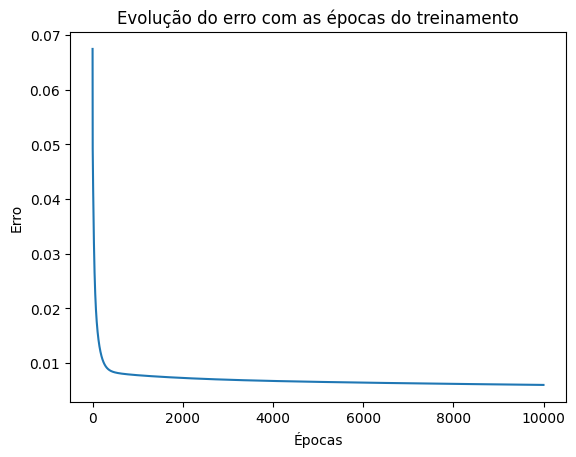

In [54]:
import matplotlib.pyplot as plt

plt.plot(erros)
plt.xlabel("Épocas")
plt.ylabel("Erro")
plt.title('Evolução do erro com as épocas do treinamento')
plt.show()

In [55]:
#Resultados finais: Erro médio quadrado (emq) na base de teste

y_pred_teste, saida = forward_pass(x_teste, peso_entrada_oculta, peso_oculta_saida)
y_verdadeiro_teste = y_teste.to_numpy().reshape(-1,1)

emq_teste = np.mean(np.square(y_pred_teste - y_verdadeiro_teste))

print(f"Erro médio quadrado no teste: {emq_teste}")

Erro médio quadrado no teste: 0.011460273190709587


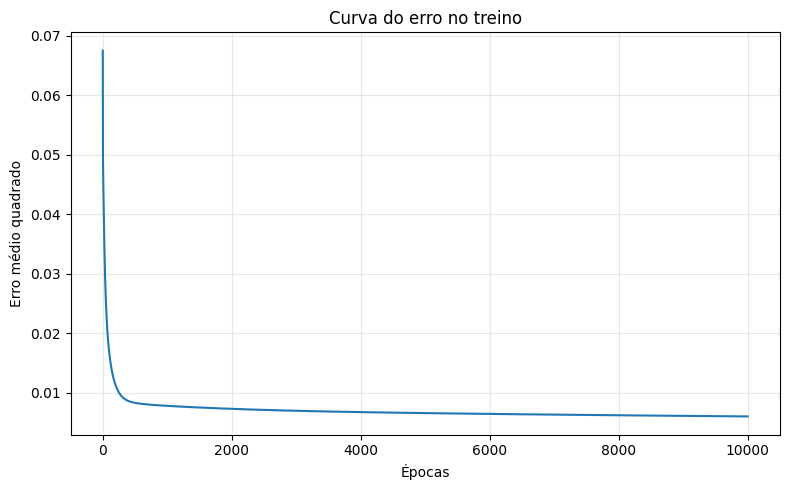

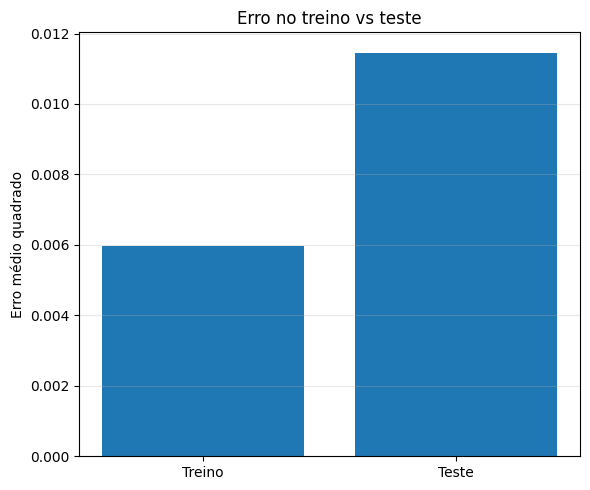

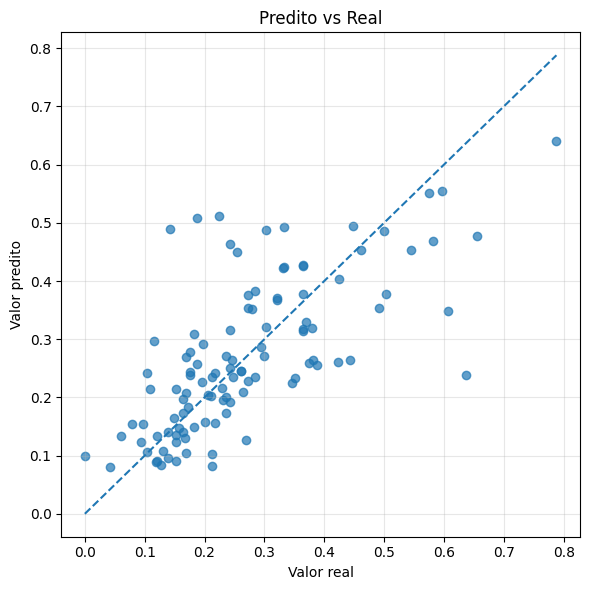

In [56]:

# -----------------------------
# 1) Curva do erro no treino
# -----------------------------
plt.figure(figsize=(8, 5))
plt.plot(erros)
plt.title("Curva do erro no treino")
plt.xlabel("Épocas")
plt.ylabel("Erro médio quadrado")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# -----------------------------
# 2) Comparação treino vs teste
# -----------------------------
y_pred_treino, _ = forward_pass(x_treino, peso_entrada_oculta, peso_oculta_saida)
y_pred_teste, _ = forward_pass(x_teste, peso_entrada_oculta, peso_oculta_saida)

y_true_treino = y_treino.to_numpy().reshape(-1, 1)
y_true_teste = y_teste.to_numpy().reshape(-1, 1)

mse_treino = np.mean((y_true_treino - y_pred_treino) ** 2)
mse_teste = np.mean((y_true_teste - y_pred_teste) ** 2)

plt.figure(figsize=(6, 5))
plt.bar(["Treino", "Teste"], [mse_treino, mse_teste])
plt.title("Erro no treino vs teste")
plt.ylabel("Erro médio quadrado")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# -----------------------------
# 3) Predito vs real
# -----------------------------
plt.figure(figsize=(6, 6))
plt.scatter(y_true_teste, y_pred_teste, alpha=0.7)

min_val = min(y_true_teste.min(), y_pred_teste.min())
max_val = max(y_true_teste.max(), y_pred_teste.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.title("Predito vs Real")
plt.xlabel("Valor real")
plt.ylabel("Valor predito")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()